In [5]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
import os
from typing import TypedDict
from pathlib import Path
import pandas as pd
import seaborn as sns

from paw_ood_pixel_error_simple import build_ensemble, plot, Ensemble, color_mapping

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
ood = Ensemble()
ood.data_to_plot = {}
output_dir = "/mnt/d/outputs/salamander/cropzoom/"

for i in range(5):
    key = f"v0.{i}.1"
    value = output_dir + f"detector_{i}/image_preds/CollectedData_new.csv/predictions.csv"
    ood.data_to_plot[key] = value

    key = f"v1.{i}.1"
    value = output_dir + f"pose_supervised_{i}/image_preds/cropped_CollectedData_new.csv/remapped_predictions.csv"
    ood.data_to_plot[key] = value
    """
    key = f"v2.{i}.1"
    value = output_dir + f"pose_ctx_{i}/image_preds/cropped_CollectedData_merged_new.csv/remapped_predictions.csv"
    ood.data_to_plot[key] = value
    """

build_ensemble(ood)


No NaN values detected in preds array.
Stddevs: [[ 1.46433476  1.02450144  2.70386032 ...  2.27069735  1.91762635
   2.25255196]
 [ 1.66450873  0.99891169  2.91471555 ...  7.37737836  7.01622036
   2.67192897]
 [ 1.27591033  1.24446185  2.65715955 ...  8.31841425  7.90980465
   7.14592466]
 ...
 [ 1.24241232  1.94859954  3.63633393 ...  3.87637757  8.13346376
   3.98755235]
 [ 1.53846631  1.28331102  3.06424584 ...  2.60574394  6.33618639
   6.69870346]
 [ 1.36922718  1.35480738  3.23803046 ... 10.26103846  7.77908655
   6.37576317]]
Total pixel error for model v0.0.1: 46412.31183084163
Total pixel error for model v1.0.1: 45812.483213560314
Total pixel error for model v0.1.1: 43646.87939723457
Total pixel error for model v1.1.1: 38277.93615570918
Total pixel error for model v0.2.1: 47535.62788556598
Total pixel error for model v1.2.1: 39839.50364121058
Total pixel error for model v0.3.1: 44476.041212532204
Total pixel error for model v1.3.1: 41397.89803750843
Total pixel error for mode

In [7]:
mask = ood.df_line2['ens-std'] == 0
mask &= ood.df_line2['model_type'] == "v0"
regular = ood.df_line2.loc[mask]['pixel_error'].mean()

mask = ood.df_line2['ens-std'] == 0
mask &= ood.df_line2['model_type'] == "v1"
cz = ood.df_line2.loc[mask]['pixel_error'].mean()

regular, cz

(11.608363639150294, 10.816584355676396)

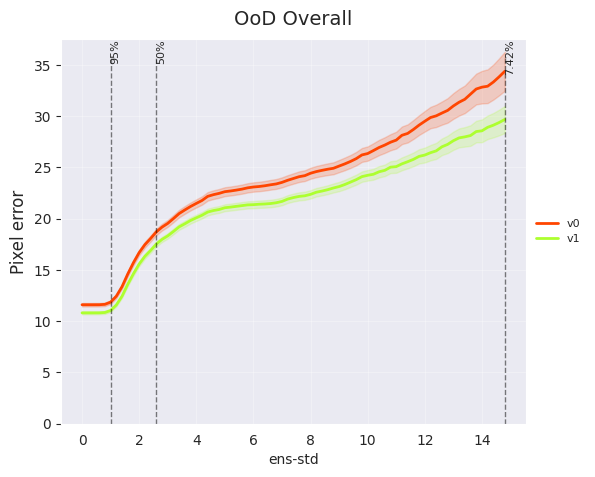

In [13]:
from paw_ood_pixel_error_simple import plot, Ensemble, color_mapping
ensembles: list[Ensemble] = [ood]

import itertools
for ind_ood, seed, model_type in itertools.product(range(2), range(5), range(3)):
    if model_type == 0:
        color = color_mapping["v0"]
    elif model_type == 1:
        color = "green" # color_mapping["v1"]
    else:
        color = color_mapping["v2"]
    color_mapping[f"v{model_type}.{seed}.{ind_ood}"] = color

fig, axes = plt.subplots(
    ncols=len(ensembles),
    nrows=1,
    figsize=(6 * len(ensembles), 5),
    sharey="row",
)
ens = ood
models_to_plot = list(ens.data_to_plot.keys())
df_line2 = ens.df_line2
n_points_dict = ens.n_points_dict
std_vals = ens.std_vals

ax = axes
plot(ax, ens, models_to_plot, "OoD")

#plt.tight_layout()
plt.savefig("salamander_cz.pdf", format="pdf", bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>